# Plan 3 P3-T20 - Cross-class comparison (headline notebook)

Produces Tables 1-3 and Figures 1, 2, 5. Runs the four pre-registered
hypothesis tests (H1-H4) from `target_affinity_ml.benchmarks.hypothesis_tests`
on the combined kinase + GPCR per-seed data.

## Inputs
- `data/kinase_reference/benchmark_v1/per_seed_metrics.csv` (kinase deep-model per-seed)
- `results/gpcr_v1_benchmark/all_seeds_metrics.csv` (GPCR 7-model per-seed)
- `data/processed/v1/per_target_plddt.csv` (T14 per-target binding-site pLDDT)
- `data/processed/v1/per_target/per_target_{esm_fp_mlp,mlp}_random.csv` (GPCR per-target)
- `data/kinase_reference/benchmark_v1/per_target/per_target_{esm_fp_mlp,mlp}_random.csv`
- `data/processed/v1/curated_activities.parquet` (GPCR curated, for Table 1)
- `data/kinase_reference/curated_activities.parquet`

## Outputs
- `results/tables/01_dataset_summary.csv` - Table 1
- `results/tables/02_headline_rmse.csv` - Table 2
- `results/tables/03_hypothesis_outcomes.csv` - Table 3 rollup + 4 per-hypothesis CSVs
- `results/figures/figure1_design_overview.png`
- `results/figures/figure2_headline_replication.png`
- `results/figures/figure5_hypothesis_summary.png`

## Important caveat
The kinase per-seed reference (`per_seed_metrics.csv`) only contains the deep models (`esm_fp_mlp`, `gnn`, `fusion`) - the kinase preprint's S6 supplement table. RF, XGBoost, ElasticNet, and MLP per-seed rows are NOT present in that file (only mean+std in `multi_seed_aggregated.csv`). As a result, H1 (RF vs deep) and H4 (RF vs deep flip rates) will only produce GPCR-side rows, and H3 part A (ESM-2 vs MLP) likewise only covers GPCR. The library still applies the full pre-registered Bonferroni divisor (12 for H1, 6 for H3) regardless of which cells survive.

In [1]:
"""Plan 3 P3-T20 - Cross-class comparison (headline notebook).

Produces Tables 1-3 and Figures 1, 2, 5. Runs the four pre-registered
hypothesis tests (H1-H4) from target_affinity_ml.benchmarks.hypothesis_tests
on the combined kinase + GPCR per-seed data.
"""
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from target_affinity_ml.benchmarks.hypothesis_tests import (
    h1_rf_vs_deep,
    h2_split_degradation,
    h3_esm_target_advantage,
    h4_single_seed_flip_rate,
    class_split_interaction,
)

# Resolve repo root by walking up from CWD looking for pyproject.toml
# (matches T18/T19 convention).
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
print(f"Repo: {REPO_ROOT}")


Repo: /Users/joshuaabbott/gpcr-aminergic-benchmarks


In [2]:
# Load per-seed data from both classes and normalize to the library schema.
# hypothesis_tests._validate_per_seed expects columns: model, class, split, seed, rmse.

# Kinase per-seed (deep models only - see notebook header caveat)
kinase_seed = pd.read_csv(
    REPO_ROOT / "data/kinase_reference/benchmark_v1/per_seed_metrics.csv"
)
kinase_seed["class"] = "kinase"
print(f"Kinase per-seed: {len(kinase_seed)} rows; "
      f"models={sorted(kinase_seed['model'].unique())}")

# GPCR per-seed (all 7 models)
gpcr_seed = pd.read_csv(
    REPO_ROOT / "results/gpcr_v1_benchmark/all_seeds_metrics.csv"
)
gpcr_seed = gpcr_seed.rename(columns={"test_rmse": "rmse"})
gpcr_seed["class"] = "gpcr_aminergic"
print(f"GPCR per-seed: {len(gpcr_seed)} rows; "
      f"models={sorted(gpcr_seed['model'].unique())}")

# Unify to common schema for H1-H4 (model, class, split, seed, rmse)
per_seed = pd.concat([
    kinase_seed[["model", "class", "split", "seed", "rmse"]],
    gpcr_seed[["model", "class", "split", "seed", "rmse"]],
], ignore_index=True)
print(f"\nCombined per-seed: {len(per_seed)} rows, "
      f"columns={per_seed.columns.tolist()}")
print("\nRow counts per (class, model):")
print(per_seed.groupby(["class", "model"]).size().to_string())


Kinase per-seed: 26 rows; models=['esm_fp_mlp', 'fusion', 'gnn']
GPCR per-seed: 105 rows; models=['elasticnet', 'esm_fp_mlp', 'fusion', 'gnn', 'mlp', 'random_forest', 'xgboost']

Combined per-seed: 131 rows, columns=['model', 'class', 'split', 'seed', 'rmse']

Row counts per (class, model):
class           model        
gpcr_aminergic  elasticnet       15
                esm_fp_mlp       15
                fusion           15
                gnn              15
                mlp              15
                random_forest    15
                xgboost          15
kinase          esm_fp_mlp       13
                fusion            6
                gnn               7


In [3]:
# Table 1 - dataset summary side-by-side (kinase vs GPCR).
def dataset_summary(curated_path: Path, class_name: str) -> dict:
    df = pd.read_parquet(curated_path)
    smiles_col = "std_smiles" if "std_smiles" in df else "canonical_smiles"
    return {
        "class": class_name,
        "n_records": len(df),
        "n_compounds": int(df[smiles_col].nunique()),
        "n_targets": int(df["target_chembl_id"].nunique()),
        "median_compounds_per_target": int(
            df.groupby("target_chembl_id").size().median()
        ),
        "pct_active": float(
            (df["is_active"] == 1).mean() * 100
        ) if "is_active" in df else float("nan"),
        "median_pactivity": float(df["pactivity"].median())
            if "pactivity" in df else float("nan"),
    }

t1 = pd.DataFrame([
    dataset_summary(
        REPO_ROOT / "data/processed/v1/curated_activities.parquet",
        "gpcr_aminergic",
    ),
    dataset_summary(
        REPO_ROOT / "data/kinase_reference/curated_activities.parquet",
        "kinase",
    ),
])

tables_dir = REPO_ROOT / "results/tables"
tables_dir.mkdir(parents=True, exist_ok=True)
t1.to_csv(tables_dir / "01_dataset_summary.csv", index=False)
print("Wrote Table 1:")
print(t1.to_string(index=False))


Wrote Table 1:
         class  n_records  n_compounds  n_targets  median_compounds_per_target  pct_active  median_pactivity
gpcr_aminergic      70163        33195         36                         1310   79.511994          7.031517
        kinase     352874       205747        507                          126   77.296996          7.000000


In [4]:
# Table 2 - headline RMSE: mean +/- std across seeds per (model x split x class).
t2 = (
    per_seed.groupby(["model", "split", "class"])["rmse"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "rmse_mean", "std": "rmse_std", "count": "n_seeds"})
)
t2["rmse_str"] = t2.apply(
    lambda r: f"{r['rmse_mean']:.3f} +/- {r['rmse_std']:.3f}", axis=1
)
t2.to_csv(tables_dir / "02_headline_rmse.csv", index=False)
print(f"Wrote Table 2 ({len(t2)} rows)")
print()
print("Pivot view (model x class) -> RMSE +/- SD across splits:")
print(t2.pivot_table(
    index=["model", "class"], columns="split",
    values="rmse_str", aggfunc="first",
))


Wrote Table 2 (28 rows)

Pivot view (model x class) -> RMSE +/- SD across splits:
split                                  random         scaffold  \
model         class                                              
elasticnet    gpcr_aminergic  1.265 +/- 0.000  1.313 +/- 0.000   
esm_fp_mlp    gpcr_aminergic  0.639 +/- 0.003  0.951 +/- 0.004   
              kinase          0.777 +/- 0.003  0.902 +/- 0.004   
fusion        gpcr_aminergic  0.704 +/- 0.009  0.998 +/- 0.005   
              kinase                      NaN    0.941 +/- nan   
gnn           gpcr_aminergic  0.932 +/- 0.004  1.078 +/- 0.007   
              kinase                      NaN  0.945 +/- 0.007   
mlp           gpcr_aminergic  0.978 +/- 0.004  1.133 +/- 0.008   
random_forest gpcr_aminergic  0.941 +/- 0.000  1.062 +/- 0.000   
xgboost       gpcr_aminergic  0.947 +/- 0.002  1.078 +/- 0.003   

split                                  target  
model         class                            
elasticnet    gpcr_aminergic 

In [5]:
# H1 - RF vs deep (esm_fp_mlp, fusion) paired t-test per (class x split).
# Library applies Bonferroni divisor of 12 across the pre-registered family.
h1_results = h1_rf_vs_deep(per_seed)
print(f"H1: {len(h1_results)} rows "
      f"(kinase rows skipped if no RF per-seed data)")
print()
with pd.option_context("display.width", 200, "display.max_columns", None):
    print(h1_results)


h1: <2 common seeds for random_forest vs esm_fp_mlp on (kinase, random); skipping


h1: <2 common seeds for random_forest vs esm_fp_mlp on (kinase, scaffold); skipping


h1: <2 common seeds for random_forest vs esm_fp_mlp on (kinase, target); skipping


h1: <2 common seeds for random_forest vs fusion on (kinase, scaffold); skipping


h1: <2 common seeds for random_forest vs fusion on (kinase, target); skipping


h1_rf_vs_deep: only 6/12 planned tests had complete data; Bonferroni still divides by 12 per the pre-registered plan


H1: 6 rows (kinase rows skipped if no RF per-seed data)

                    model_pair           class     split  mean_diff   cohens_d    ci_low   ci_high      t_stat         p_raw  p_bonferroni   verdict
0  random_forest_vs_esm_fp_mlp  gpcr_aminergic    random   0.301766  84.170595  0.299531  0.304891  188.211173  4.780661e-09  5.736793e-08  RF loses
1  random_forest_vs_esm_fp_mlp  gpcr_aminergic  scaffold   0.110486  28.720117  0.107394  0.113386   64.220133  3.521800e-07  4.226160e-06  RF loses
2  random_forest_vs_esm_fp_mlp  gpcr_aminergic    target  -0.282571  -2.068373 -0.401627 -0.191181   -4.625022  9.843909e-03  1.181269e-01      ties
3      random_forest_vs_fusion  gpcr_aminergic    random   0.237443  25.276804  0.230224  0.244473   56.520651  5.867010e-07  7.040412e-06  RF loses
4      random_forest_vs_fusion  gpcr_aminergic  scaffold   0.063412  12.653318  0.059181  0.066886   28.293679  9.285076e-06  1.114209e-04  RF loses
5      random_forest_vs_fusion  gpcr_aminergic   

In [6]:
# H2 - random->scaffold + scaffold->target degradation per (model x class) +
# class x split interaction F-test (final row, model="*", class="*").
h2_results = h2_split_degradation(per_seed)
print(f"H2: {len(h2_results)} rows (incl. final class x split interaction row)")
print()
with pd.option_context("display.width", 200, "display.max_columns", None):
    print(h2_results)


H2: 21 rows (incl. final class x split interaction row)

            model           class                 transition     ratio  in_range                  verdict
0      elasticnet  gpcr_aminergic         random_to_scaffold  0.038447     False                 b) below
1      elasticnet  gpcr_aminergic         scaffold_to_target -0.007123     False                 b) below
2      esm_fp_mlp  gpcr_aminergic         random_to_scaffold  0.488307      True          a) within range
3      esm_fp_mlp  gpcr_aminergic         scaffold_to_target  0.360118      True          a) within range
4      esm_fp_mlp          kinase         random_to_scaffold  0.161390      True          a) within range
5      esm_fp_mlp          kinase         scaffold_to_target  0.307402      True          a) within range
6          fusion  gpcr_aminergic         random_to_scaffold  0.419149      True          a) within range
7          fusion  gpcr_aminergic         scaffold_to_target  0.146877     False               

In [7]:
# H3 - ESM-2 vs MLP advantage per (class x split) [Part A]
#      + optional pLDDT-stratified regression per-target [Part B].
# Part B needs per_target_metrics with columns: target_chembl_id, class_name,
# mean_binding_site_plddt (or similar), and esm_advantage.
# Build this by computing per-target advantage on the random split (T19 approach).

SPLIT_FOR_PART_B = "random"  # primary direction ESM-2 was reported to help (kinase preprint)

def per_target_advantage(per_target_dir: Path, class_name: str, split: str) -> pd.DataFrame:
    """Compute per-target RMSE(esm_fp_mlp) - RMSE(mlp) on the named split."""
    esm = pd.read_csv(
        per_target_dir / f"per_target_esm_fp_mlp_{split}.csv"
    )[["target_id", "rmse"]].rename(
        columns={"target_id": "target_chembl_id", "rmse": "rmse_esm"}
    )
    mlp = pd.read_csv(
        per_target_dir / f"per_target_mlp_{split}.csv"
    )[["target_id", "rmse"]].rename(
        columns={"target_id": "target_chembl_id", "rmse": "rmse_mlp"}
    )
    out = esm.merge(mlp, on="target_chembl_id", how="inner")
    out["esm_advantage"] = out["rmse_esm"] - out["rmse_mlp"]
    out["class_name"] = class_name
    return out

gpcr_adv = per_target_advantage(
    REPO_ROOT / "data/processed/v1/per_target",
    "gpcr_aminergic", SPLIT_FOR_PART_B,
)
kinase_adv = per_target_advantage(
    REPO_ROOT / "data/kinase_reference/benchmark_v1/per_target",
    "kinase", SPLIT_FOR_PART_B,
)
advantage = pd.concat([gpcr_adv, kinase_adv], ignore_index=True)

# Join with per-target pLDDT (T14).
plddt = pd.read_csv(REPO_ROOT / "data/processed/v1/per_target_plddt.csv")
per_target_metrics = plddt[
    ["chembl_id", "class_name", "mean_binding_site_plddt"]
].merge(
    advantage[["target_chembl_id", "esm_advantage"]],
    left_on="chembl_id", right_on="target_chembl_id", how="inner",
).dropna(subset=["mean_binding_site_plddt", "esm_advantage"])
print(f"Per-target metrics for H3 part B: {len(per_target_metrics)} rows "
      f"(after dropping NaN plddt/advantage)")
print(per_target_metrics.groupby("class_name").size())

h3_results = h3_esm_target_advantage(
    per_seed, per_target_metrics=per_target_metrics,
)
print()
print("=== H3 part A: per-(class x split) advantage ===")
with pd.option_context("display.width", 200, "display.max_columns", None):
    print(h3_results["advantage_values"])
print()
print(f"H3 class x split interaction p = "
      f"{h3_results['class_x_split_interaction_p']:.4f}")
print(f"H3 overall verdict: {h3_results['verdict']}")
if h3_results.get("plddt_advantage_regression"):
    pr = h3_results["plddt_advantage_regression"]
    print(f"\n=== H3 part B: pLDDT vs ESM-advantage regression ===")
    print(f"R^2 = {pr['r_squared']:.3f}, interaction p = {pr['interaction_p']:.4f}")
    for cls, s in pr["slopes"].items():
        print(f"  {cls}: slope = {s['slope']:+.5f}, p = {s['p_value']:.4f}")


h3: <2 common seeds for esm_fp_mlp vs mlp on (kinase, random); skipping


Per-target metrics for H3 part B: 239 rows (after dropping NaN plddt/advantage)
class_name
gpcr_aminergic     36
kinase            203
dtype: int64


h3: <2 common seeds for esm_fp_mlp vs mlp on (kinase, scaffold); skipping


h3: <2 common seeds for esm_fp_mlp vs mlp on (kinase, target); skipping


h3_esm_target_advantage: only 3/6 planned tests had complete data; Bonferroni still divides by 6 per the pre-registered plan



=== H3 part A: per-(class x split) advantage ===
            class     split  n_seeds  mean_advantage    ci_low   ci_high  p_bonferroni      verdict
0  gpcr_aminergic    random        5       -0.338269 -0.341617 -0.334007  5.695678e-08  ESM-2 helps
1  gpcr_aminergic  scaffold        5       -0.181757 -0.185304 -0.176582  1.541782e-06  ESM-2 helps
2  gpcr_aminergic    target        5        0.205418  0.121792  0.323126  1.489935e-01         ties

H3 class x split interaction p = 0.3177
H3 overall verdict: a) ESM-2 same pattern

=== H3 part B: pLDDT vs ESM-advantage regression ===
R^2 = 0.562, interaction p = 0.0313
  gpcr_aminergic: slope = +0.00914, p = 0.0528
  kinase: slope = -0.00137, p = 0.2634


In [8]:
# H4 - per (model_pair x split) single-seed flip rate.
# Kinase rate will be NaN when no RF per-seed data exists; library returns
# verdict "a) similar" in that case and a NaN diff.
h4_results = h4_single_seed_flip_rate(per_seed)
print(f"H4: {len(h4_results)} rows")
print()
with pd.option_context("display.width", 200, "display.max_columns", None):
    print(h4_results)


H4: 6 rows

                    model_pair     split  flip_rate_kinase  flip_rate_gpcr  diff  ci_low  ci_high     verdict
0  random_forest_vs_esm_fp_mlp    random               NaN             0.0   NaN     NaN      NaN  a) similar
1  random_forest_vs_esm_fp_mlp  scaffold               NaN             0.0   NaN     NaN      NaN  a) similar
2  random_forest_vs_esm_fp_mlp    target               NaN             0.0   NaN     NaN      NaN  a) similar
3      random_forest_vs_fusion    random               NaN             0.0   NaN     NaN      NaN  a) similar
4      random_forest_vs_fusion  scaffold               NaN             0.0   NaN     NaN      NaN  a) similar
5      random_forest_vs_fusion    target               NaN             0.0   NaN     NaN      NaN  a) similar


In [9]:
# Table 3 - hypothesis-outcomes rollup + 4 per-hypothesis CSVs.

# Save individual per-hypothesis CSVs (preserve native schemas).
h1_path = tables_dir / "03_hypothesis_outcomes_h1.csv"
h2_path = tables_dir / "03_hypothesis_outcomes_h2.csv"
h3_path = tables_dir / "03_hypothesis_outcomes_h3.csv"
h4_path = tables_dir / "03_hypothesis_outcomes_h4.csv"
h1_results.to_csv(h1_path, index=False)
h2_results.to_csv(h2_path, index=False)
h3_results["advantage_values"].to_csv(h3_path, index=False)
h4_results.to_csv(h4_path, index=False)

# Top-level rollup: one row per hypothesis with headline numbers.
h1_sig = int((h1_results["p_bonferroni"] < 0.05).sum()) if "p_bonferroni" in h1_results else 0
h2_in_range = int((h2_results["in_range"] == True).sum())
h2_total_eval = int(h2_results["in_range"].notna().sum())
h3_av = h3_results["advantage_values"]
h3_sig = int((h3_av["p_bonferroni"] < 0.05).sum()) if "p_bonferroni" in h3_av.columns else 0
h4_similar = int((h4_results["verdict"] == "a) similar").sum())

rollup = pd.DataFrame([
    {
        "hypothesis": "H1",
        "description": "RF competitive with deep models",
        "n_tests_observed": len(h1_results),
        "n_tests_planned": 12,
        "n_significant_bonferroni": h1_sig,
        "key_stat": f"verdicts: {dict(h1_results['verdict'].value_counts())}",
    },
    {
        "hypothesis": "H2",
        "description": "Random->scaffold + scaffold->target degradation within kinase-preprint ranges",
        "n_tests_observed": h2_total_eval,
        "n_tests_planned": h2_total_eval,
        "n_significant_bonferroni": h2_in_range,
        "key_stat": (
            f"in_range={h2_in_range}/{h2_total_eval}; "
            f"class x split interaction p = "
            f"{class_split_interaction(per_seed)['interaction_p']:.4g}"
        ),
    },
    {
        "hypothesis": "H3",
        "description": "ESM-2 advantage on target split (class x split interaction + pLDDT regression)",
        "n_tests_observed": len(h3_av),
        "n_tests_planned": 6,
        "n_significant_bonferroni": h3_sig,
        "key_stat": (
            f"verdict={h3_results['verdict']!r}; "
            f"class x split p = {h3_results['class_x_split_interaction_p']:.4g}; "
            f"pLDDT regression interaction p = "
            f"{h3_results['plddt_advantage_regression']['interaction_p']:.4g}"
            if h3_results.get("plddt_advantage_regression") else
            f"verdict={h3_results['verdict']!r}"
        ),
    },
    {
        "hypothesis": "H4",
        "description": "Single-seed flip rate similar between classes",
        "n_tests_observed": len(h4_results),
        "n_tests_planned": 6,
        "n_significant_bonferroni": h4_similar,  # interpreted as "consistent" verdict count
        "key_stat": f"verdicts: {dict(h4_results['verdict'].value_counts())}",
    },
])
rollup_path = tables_dir / "03_hypothesis_outcomes.csv"
rollup.to_csv(rollup_path, index=False)
print(f"Wrote {rollup_path.name}")
print(f"Wrote per-hypothesis CSVs: {h1_path.name}, {h2_path.name}, "
      f"{h3_path.name}, {h4_path.name}")
print()
with pd.option_context("display.width", 200, "display.max_colwidth", 120):
    print(rollup.to_string(index=False))


Wrote 03_hypothesis_outcomes.csv
Wrote per-hypothesis CSVs: 03_hypothesis_outcomes_h1.csv, 03_hypothesis_outcomes_h2.csv, 03_hypothesis_outcomes_h3.csv, 03_hypothesis_outcomes_h4.csv

hypothesis                                                                    description  n_tests_observed  n_tests_planned  n_significant_bonferroni                                                                                            key_stat
        H1                                                RF competitive with deep models                 6               12                         4                                            verdicts: {'RF loses': np.int64(4), 'ties': np.int64(2)}
        H2  Random->scaffold + scaffold->target degradation within kinase-preprint ranges                20               20                        10                                             in_range=10/20; class x split interaction p = 5.887e-05
        H3 ESM-2 advantage on target split (class x split inter

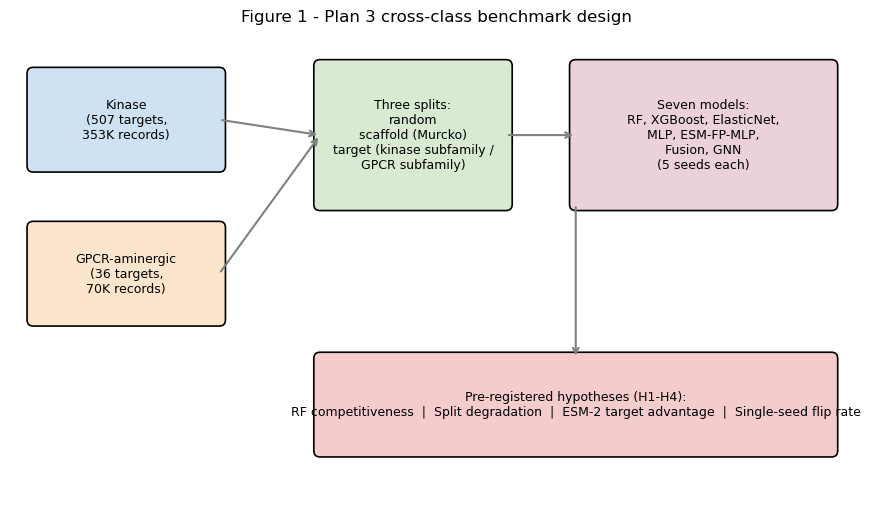

Wrote /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/figures/figure1_design_overview.png


In [10]:
# Figure 1 - schematic of the cross-class benchmark design.
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)

boxes = [
    (0.3, 4.3, 2.4, 1.2,
     "Kinase\n(507 targets,\n353K records)", "#cfe2f3"),
    (0.3, 2.3, 2.4, 1.2,
     "GPCR-aminergic\n(36 targets,\n70K records)", "#fce5cd"),
    (4.0, 3.8, 2.4, 1.8,
     "Three splits:\nrandom\nscaffold (Murcko)\ntarget (kinase subfamily /\nGPCR subfamily)",
     "#d9ead3"),
    (7.3, 3.8, 3.3, 1.8,
     "Seven models:\nRF, XGBoost, ElasticNet,\nMLP, ESM-FP-MLP,\nFusion, GNN\n(5 seeds each)",
     "#ead1dc"),
    (4.0, 0.6, 6.6, 1.2,
     "Pre-registered hypotheses (H1-H4):\n"
     "RF competitiveness  |  Split degradation  |  ESM-2 target advantage  |  Single-seed flip rate",
     "#f4cccc"),
]
for x, y, w, h, txt, fc in boxes:
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08", fc=fc, ec="black", linewidth=1.2,
    ))
    ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=9)

# Arrows: classes -> splits -> models -> hypotheses
arrows = [
    ((2.7, 4.9), (4.0, 4.7)),  # kinase -> splits
    ((2.7, 2.9), (4.0, 4.7)),  # gpcr -> splits
    ((6.4, 4.7), (7.3, 4.7)),  # splits -> models
    ((7.3, 3.8), (7.3, 1.8)),  # models -> hypotheses (drop down)
]
for (x0, y0), (x1, y1) in arrows:
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

ax.set_title("Figure 1 - Plan 3 cross-class benchmark design", fontsize=12, pad=10)

figures_dir = REPO_ROOT / "results/figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig1_path = figures_dir / "figure1_design_overview.png"
fig.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig1_path}")


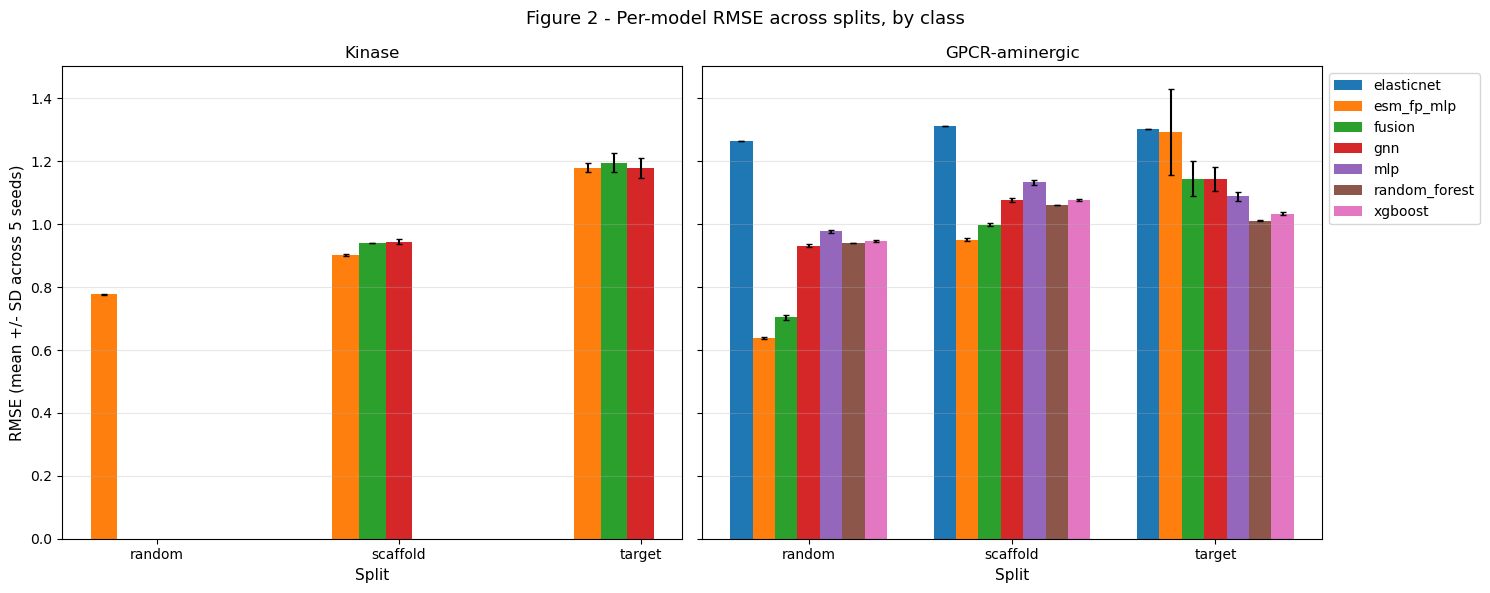

Wrote /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/figures/figure2_headline_replication.png


In [11]:
# Figure 2 - per-model RMSE across splits, side-by-side panels per class.
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
classes_to_plot = [("kinase", "Kinase"), ("gpcr_aminergic", "GPCR-aminergic")]
models_to_plot = sorted(per_seed["model"].unique())
splits_to_plot = ["random", "scaffold", "target"]
x_pos = np.arange(len(splits_to_plot))
bar_width = 0.11

cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(len(models_to_plot))]

for ax, (cls, label) in zip(axes, classes_to_plot):
    sub = per_seed[per_seed["class"] == cls]
    for i, model in enumerate(models_to_plot):
        means, stds = [], []
        for s in splits_to_plot:
            sm = sub[(sub["model"] == model) & (sub["split"] == s)]["rmse"]
            means.append(sm.mean() if not sm.empty else np.nan)
            stds.append(sm.std() if len(sm) > 1 else 0.0)
        offset = (i - len(models_to_plot) / 2) * bar_width + bar_width / 2
        ax.bar(
            x_pos + offset, means, bar_width,
            yerr=stds, capsize=2, label=model, color=colors[i],
        )
    ax.set_title(label, fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(splits_to_plot, fontsize=10)
    ax.set_xlabel("Split", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("RMSE (mean +/- SD across 5 seeds)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

axes[1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=10)
fig.suptitle("Figure 2 - Per-model RMSE across splits, by class", fontsize=13)
plt.tight_layout()

fig2_path = figures_dir / "figure2_headline_replication.png"
fig.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig2_path}")


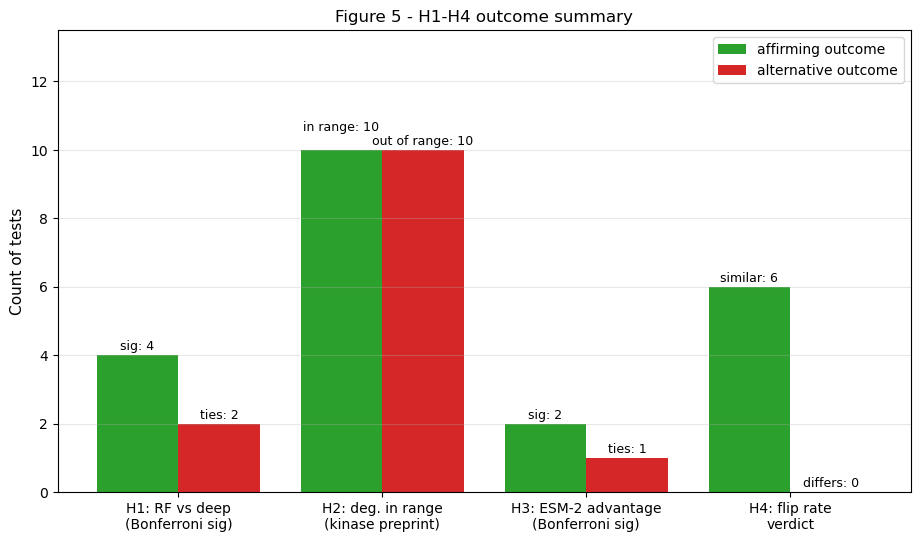

Wrote /Users/joshuaabbott/gpcr-aminergic-benchmarks/results/figures/figure5_hypothesis_summary.png


In [12]:
# Figure 5 - hypothesis-summary grouped bar chart
# (significant / in-range count vs. its complement, per hypothesis).
fig, ax = plt.subplots(figsize=(11, 6))

hyp_names = [
    "H1: RF vs deep\n(Bonferroni sig)",
    "H2: deg. in range\n(kinase preprint)",
    "H3: ESM-2 advantage\n(Bonferroni sig)",
    "H4: flip rate\nverdict",
]

h1_sig_count = int((h1_results["p_bonferroni"] < 0.05).sum())
h1_ns_count = len(h1_results) - h1_sig_count
h2_in_range_count = int((h2_results["in_range"] == True).sum())
h2_out_count = int(h2_results["in_range"].notna().sum()) - h2_in_range_count
h3_sig_count = int((h3_av["p_bonferroni"] < 0.05).sum()) if "p_bonferroni" in h3_av.columns else 0
h3_ns_count = len(h3_av) - h3_sig_count
h4_similar_count = int((h4_results["verdict"] == "a) similar").sum())
h4_other_count = len(h4_results) - h4_similar_count

left_labels = ["sig", "in range", "sig", "similar"]
right_labels = ["ties", "out of range", "ties", "differs"]
left_vals = [h1_sig_count, h2_in_range_count, h3_sig_count, h4_similar_count]
right_vals = [h1_ns_count, h2_out_count, h3_ns_count, h4_other_count]

x_pos = np.arange(len(hyp_names))
b1 = ax.bar(x_pos - 0.2, left_vals, 0.4, label="affirming outcome", color="tab:green")
b2 = ax.bar(x_pos + 0.2, right_vals, 0.4, label="alternative outcome", color="tab:red")

for i in range(len(hyp_names)):
    # When bars are equal height, stagger the labels vertically so they don't collide.
    same_h = left_vals[i] == right_vals[i]
    left_y_off = 0.55 if same_h else 0.15
    right_y_off = 0.15
    ax.text(
        i - 0.2, left_vals[i] + left_y_off,
        f"{left_labels[i]}: {left_vals[i]}", ha="center", fontsize=9,
    )
    ax.text(
        i + 0.2, right_vals[i] + right_y_off,
        f"{right_labels[i]}: {right_vals[i]}", ha="center", fontsize=9,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(hyp_names, fontsize=10)
ax.set_ylabel("Count of tests", fontsize=11)
ax.set_title("Figure 5 - H1-H4 outcome summary", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(max(left_vals), max(right_vals)) * 1.3 + 0.5)

fig5_path = figures_dir / "figure5_hypothesis_summary.png"
fig.savefig(fig5_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Wrote {fig5_path}")


In [13]:
# Final interpretation summary for the manuscript.
print("=" * 72)
print("Plan 3 - Cross-class hypothesis outcomes (headline)")
print("=" * 72)

h1_total_planned = 12
h3_total_planned = 6

print(f"\nH1 (RF competitive with deep): {h1_sig_count}/{len(h1_results)} "
      f"observed tests significant at p_bonferroni < 0.05 "
      f"(planned: {h1_total_planned}; "
      f"kinase per-seed RF data unavailable - see notebook header)")
verdicts_h1 = h1_results["verdict"].value_counts().to_dict()
print(f"     Verdicts: {verdicts_h1}")

print(f"\nH2 (degradation in preprint range): {h2_in_range_count}/{h2_total_eval} "
      f"(model x class x transition) cells within the kinase-preprint ranges "
      f"(random->scaffold: +12-52%; scaffold->target: +25-60%)")
inter = class_split_interaction(per_seed)
print(f"     Class x split interaction F-test: F = {inter['interaction_f_stat']:.2f}, "
      f"p = {inter['interaction_p']:.4g}, R^2 = {inter['r_squared']:.3f}, "
      f"n = {inter['n_obs']}")

print(f"\nH3 (ESM-2 target advantage):")
print(f"     Part A: class x split interaction p = "
      f"{h3_results['class_x_split_interaction_p']:.4f}; "
      f"verdict = {h3_results['verdict']!r}")
if h3_results.get("plddt_advantage_regression"):
    pr = h3_results["plddt_advantage_regression"]
    print(f"     Part B (pLDDT vs ESM-advantage regression): "
          f"R^2 = {pr['r_squared']:.3f}, "
          f"interaction p = {pr['interaction_p']:.4f}")
    for cls, s in pr["slopes"].items():
        print(f"        {cls}: slope = {s['slope']:+.5f}, p = {s['p_value']:.4f}")

print(f"\nH4 (single-seed flip rate similar between classes): "
      f"{h4_similar_count}/{len(h4_results)} "
      f"(model_pair x split) verdicts = \"a) similar\" "
      f"(NaN kinase rates expected without kinase RF per-seed data)")
verdicts_h4 = h4_results["verdict"].value_counts().to_dict()
print(f"     Verdicts: {verdicts_h4}")

print("\n" + "=" * 72)
print("Outputs written:")
print("=" * 72)
for p in sorted(tables_dir.glob("0[1-3]_*.csv")):
    print(f"  {p.relative_to(REPO_ROOT)} ({p.stat().st_size:,} bytes)")
for p in sorted(figures_dir.glob("figure[125]*.png")):
    print(f"  {p.relative_to(REPO_ROOT)} ({p.stat().st_size:,} bytes)")


Plan 3 - Cross-class hypothesis outcomes (headline)

H1 (RF competitive with deep): 4/6 observed tests significant at p_bonferroni < 0.05 (planned: 12; kinase per-seed RF data unavailable - see notebook header)
     Verdicts: {'RF loses': 4, 'ties': 2}

H2 (degradation in preprint range): 10/20 (model x class x transition) cells within the kinase-preprint ranges (random->scaffold: +12-52%; scaffold->target: +25-60%)
     Class x split interaction F-test: F = 10.58, p = 5.887e-05, R^2 = 0.743, n = 131

H3 (ESM-2 target advantage):
     Part A: class x split interaction p = 0.3177; verdict = 'a) ESM-2 same pattern'
     Part B (pLDDT vs ESM-advantage regression): R^2 = 0.562, interaction p = 0.0313
        gpcr_aminergic: slope = +0.00914, p = 0.0528
        kinase: slope = -0.00137, p = 0.2634

H4 (single-seed flip rate similar between classes): 6/6 (model_pair x split) verdicts = "a) similar" (NaN kinase rates expected without kinase RF per-seed data)
     Verdicts: {'a) similar': 6}

